In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np

import datetime
import pytz
NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC") 

In [2]:
import rateslib as rl
import QuantLib as ql

from Query.IRSwaps.IRSwapQuery import IRSwapQuery, IRSwapStructure
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from TB.IRSwapsTB import IRSwapsTB

from utils.ql_utils import datetime_to_ql_date, ql_date_to_datetime 

In [3]:
# import logging, sys
# for h in logging.root.handlers[:]:
#     logging.root.removeHandler(h)
# logging.basicConfig(
#     level=logging.ERROR,  # or DEBUG
#     stream=sys.stdout,  # send logs to the cell output
#     format="%(asctime)s %(levelname)s [%(name)s] %(message)s",
# )
# logging.getLogger("IRSwapsTB").setLevel(logging.ERROR)
# logging.captureWarnings(True)

import logging
logging.disable(logging.CRITICAL)

In [10]:
# 2025-09-20 18:09:30,966 CRITICAL [ZODB.DB] DB.open() has 19 open connections with a pool_size of 7

In [10]:
# curve_mdp = IRSwapsMDP(source="CME_NY_EOD_LIVE-ql_basic")
# curve_mdp = IRSwapsMDP(source="GSQUANT-rl_basic")
curve_mdp = IRSwapsMDP(source="SDR_INTRADAY-rl_usd_sofr_mt_q12")
# curve_mdp = IRSwapsMDP(source="SDR_INTRADAY-rl_usd_ois_stir_q12x12", force_refresh_fixings=True)
irs_tb = IRSwapsTB(mdp=curve_mdp, force_refresh=True)

SUCCESS: `conv_tol` reached after 4 iterations (levenberg_marquardt), `f_val`: 0.00043054887180480375, `time`: 0.1221s
SUCCESS: `conv_tol` reached after 4 iterations (levenberg_marquardt), `f_val`: 30767.409340992348, `time`: 0.1159s


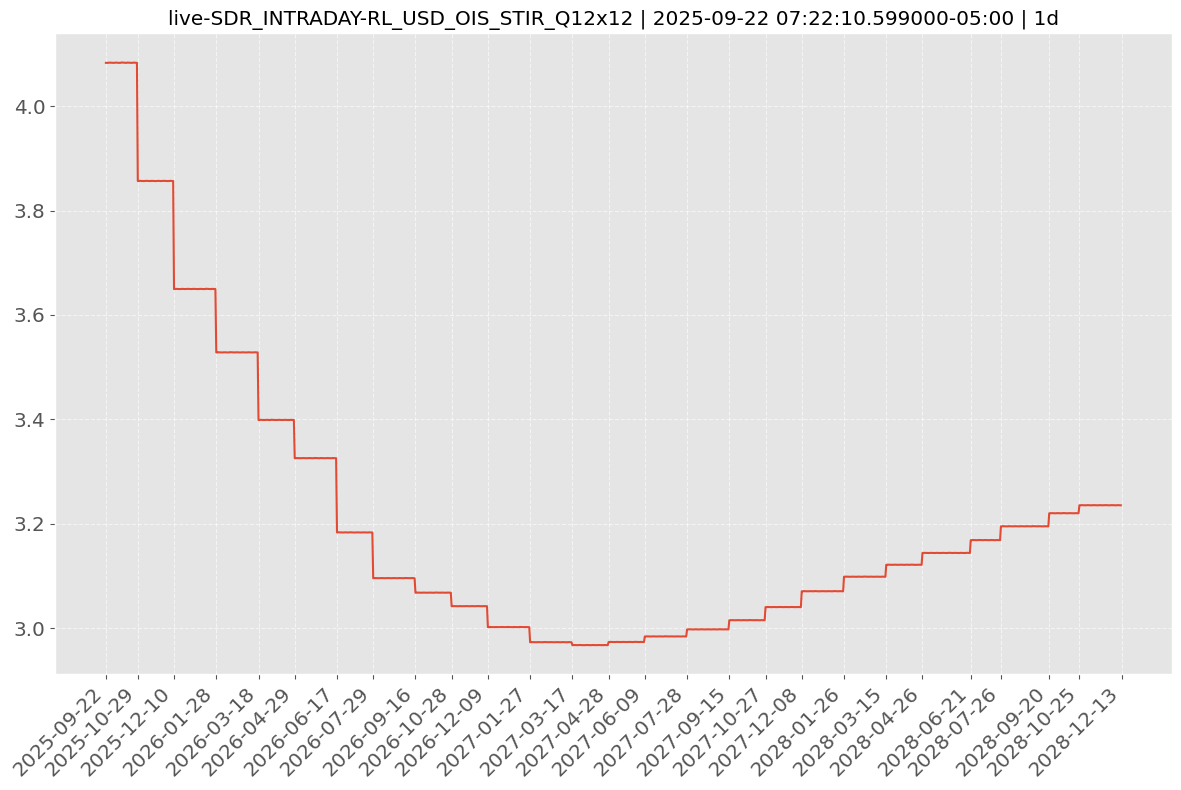

In [96]:
# ts = NY_tz.localize(datetime.datetime(2025, 9, 19, 17, 00))
ts = "live"
# live_curve = curve_mdp._get_curve(curve_name="USD-SOFR-1D", timestamp=ts, kwargs={"force_refresh": True})
# live_curve = curve_mdp._get_curve(curve_name="USD-FEDFUNDS", timestamp=ts, kwargs={"force_refresh": True})
live_curve = curve_mdp._get_curve(curve_name="USD-FEDFUNDS", timestamp=ts)

x_data_num, y_data_rate = live_curve.handle()._plot_rates("1d", left=rl.NoInput(0), right=rl.NoInput(0))
plot_data_dict = dict(zip(x_data_num, [y.real for y in y_data_rate]))

calendar = ql.UnitedStates(ql.UnitedStates.FederalReserve)
filtered_plot_data = {dt: rate for dt, rate in plot_data_dict.items() if calendar.isBusinessDay(ql.Date(dt.day, dt.month, dt.year))}

x_business_days = list(filtered_plot_data.keys())
y_business_rates = list(filtered_plot_data.values())


fig, ax = plt.subplots()
ax.plot(x_business_days, y_business_rates)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=45, ha="right")  # Rotate ticks for better readability
ax.grid(True, linestyle="--", alpha=0.6)

curve_nodes = live_curve.handle().nodes._nodes.keys()
ticks = [t.tz_localize(None) if getattr(t, "tzinfo", None) else t for t in curve_nodes]
ax.set_xticks(mdates.date2num(ticks))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.title(f"{live_curve.meta()["id"]} | {live_curve.meta()["timestamp"]} | 1d")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
# today = live_curve.handle().referenceDate()

# end = today + ql.Period(30, ql.Years)
# dates = [
#     ql.Date(serial)
#     for serial in range(today.serialNumber(), end.serialNumber() + 1)
# ]
# rates_ff = [
#     live_curve.handle().forwardRate(
#         d, live_curve.calendar().advance(d, 1, ql.Days), ql.Actual360(), ql.Simple
#     ).rate()
#     for d in dates
# ]

# ax = plt.figure(figsize=(9, 6)).add_subplot(1, 1, 1)
# ax.set_xlim(min(dates).to_date(), max(dates).to_date())
# ax.plot([d.to_date() for d in dates], rates_ff, "-")

In [5]:
# def extract_fitted_curve_nodes(fitted_curve: ql.YieldTermStructure, num_points = 10000):
#     start_date: ql.Date = fitted_curve.referenceDate()
#     end_date: ql.Date = fitted_curve.maxDate()
#     grid_serials = np.linspace(start_date.serialNumber(), end_date.serialNumber(), num_points).astype(int)
#     grid_dates = [ql.Date(int(s)) for s in grid_serials]
#     return {ql_date_to_datetime(date): fitted_curve.discount(date) for date in grid_dates}

# qlirswapcurve = curve_mdp.get_data({"curve_name": "USD-SOFR-1D", "timestamp": datetime.date(2025, 9, 2)})
# h: ql.YieldTermStructureHandle = qlirswapcurve.handle()
# extract_fitted_curve_nodes(h)

In [18]:
# q = IRSwapQuery(curve="USD-SOFR-1D", structure=IRSwapStructure.CURVE, structure_kwargs={"front_tenor": "2Y", "back_tenor": "10Y", "bpv": 1})
q = IRSwapQuery(curve="USD-SOFR-1D", tenor="10Y")
df = irs_tb.get_timeseries(start=datetime.date(2025, 8, 1), end=datetime.date(2025, 9, 19), queries=[q], n_jobs=1, ignore_cache=True)
df

PRICING IRSWAPS...: 100%|██████████| 36/36 [00:00<00:00, 152.47it/s]


,USD-SOFR-1D 10Y OUTRIGHT RATE
Date,
2025-08-01,3.700329
2025-08-04,3.675146
2025-08-05,3.669350
2025-08-06,3.697831
2025-08-07,3.714162
2025-08-08,3.751706
2025-08-11,3.746255
2025-08-12,3.761300
2025-08-13,3.711054


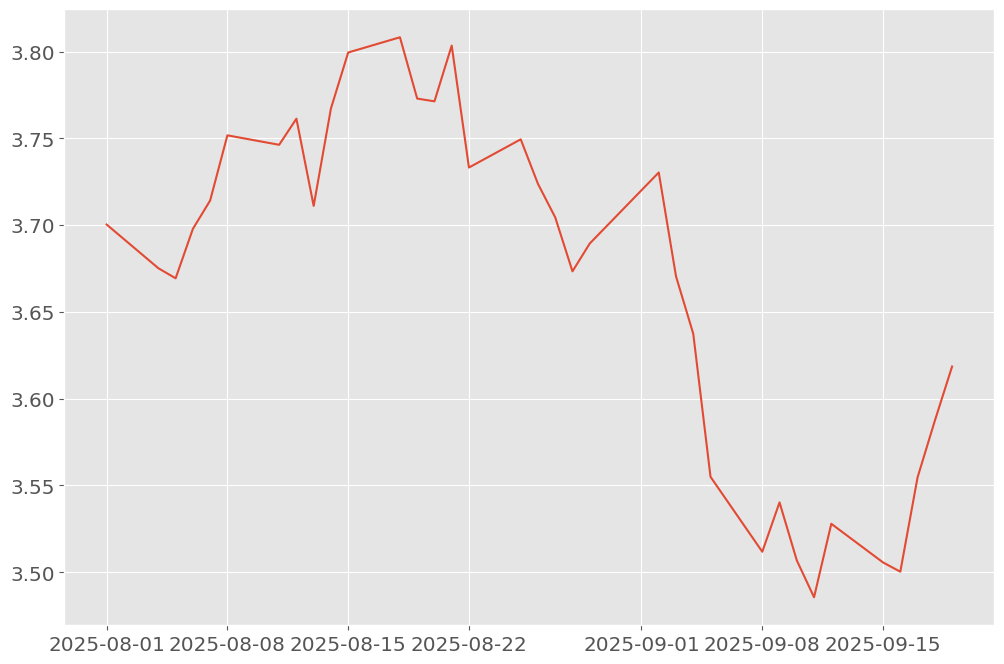

In [19]:
plt.plot(df.index, df[q.col_name()])

In [22]:
fomc_dated_ois = {
    # "sep25": (rl.dt(2025, 9, 17), rl.dt(2025, 10, 29)),
    "oct25": (rl.dt(2025, 10, 29), rl.dt(2025, 12, 10)),
    "dec25": (rl.dt(2025, 12, 10), rl.dt(2026, 1, 28)),
    "jan26": (rl.dt(2026, 1, 28), rl.dt(2026, 3, 18)),
    "mar26": (rl.dt(2026, 3, 18), rl.dt(2026, 4, 29)),
    "apr26": (rl.dt(2026, 4, 29), rl.dt(2026, 6, 17)),
    "jun26": (rl.dt(2026, 6, 17), rl.dt(2026, 7, 29)),
    "jul26": (rl.dt(2026, 7, 29), rl.dt(2026, 9, 16)),
    "sep26": (rl.dt(2026, 9, 16), rl.dt(2026, 10, 28)),
    "oct26": (rl.dt(2026, 10, 28), rl.dt(2026, 12, 9)),
    "dec26": (rl.dt(2026, 12, 9), rl.dt(2027, 1, 27)),
}


def build_fomc_ois(meeting: str, rl_curve: rl.Curve, risk=None, notional=None, rl_irs_swap_kargs={}):
    assert risk is not None or notional is not None, "Must pass in `risk` or `notional`"

    if risk is not None:
        unit_delta = rl.IRS(
            effective=fomc_dated_ois[meeting][0], termination=fomc_dated_ois[meeting][1], spec="usd_irs_lt_2y", curves=rl_curve, notional=1
        ).analytic_delta(rl_curve)
        notional = risk / unit_delta

    fomc_swap = rl.IRS(
        effective=fomc_dated_ois[meeting][0], termination=fomc_dated_ois[meeting][1], spec="usd_irs_lt_2y", curves=rl_curve, notional=notional, **rl_irs_swap_kargs
    )
    return fomc_swap

In [ ]:
oct25 : 3.870283
dec25 : 3.648781
jan26 : 3.526555
mar26 : 3.406128
apr26 : 3.334102
jun26 : 3.194009

In [56]:
import requests
headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_10_1) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/39.0.2171.95 Safari/537.36'}
url = "https://sdrview.clarusft.com/"
r = requests.get(url, headers=headers, allow_redirects=True)

In [ ]:
ql.LogMixedLinearCubicDiscountCurve

r"""__init__(
LogMixedLinearCubicDiscountCurve self, 
DateVector dates, 
DoubleVector discounts, 
DayCounter dayCounter, 
Calendar calendar=Calendar(), 
LogMixedLinearCubic i=LogMixedLinearCubic()) -> LogMixedLinearCubicDiscountCurve"""


r"""__init__(
LogMixedLinearCubic self, 
Size n=0, 
MixedInterpolation::Behavior behavior=ShareRanges, 
CubicInterpolation::DerivativeApprox da=Spline, 
bool monotonic=True) -> LogMixedLinearCubic"""


200


In [ ]:
ql.PiecewiseLogMixedLinearCubicDiscount(date, helpers, calendar, [], [], ql.LogMixedLinearCubic(n, ql.MixedInterpolation.SplitRanges)) # jumps and jumpDates are empty
ql.PiecewiseLogMixedLinearCubicDiscount
ql.LogMixedLinearCubicDiscountCurve

In [98]:
# import requests
# requests.get("https://www.bondsupermart.com/main/ws/v4/bond-info/bond-factsheet-chart/US912810UA42").json()["yieldChartMap"]["SINCE_INCEPTION"]

In [4]:
from MDP.IRSwaps.SDR_INTRADAY.rl_curve_utils.rl_usd_sofr_mt_builder_parallel import rl_usd_sofr_mt_builder_parallel

In [5]:
start = NY_tz.localize(datetime.datetime(2025, 9, 17, 7, 00))
end = NY_tz.localize(datetime.datetime(2025, 9, 17, 17, 00))
intraday_range = pd.date_range(start=start, end=end, freq="1min")
intraday_range[300:310]

DatetimeIndex(['2025-09-17 12:00:00-04:00', '2025-09-17 12:01:00-04:00',
               '2025-09-17 12:02:00-04:00', '2025-09-17 12:03:00-04:00',
               '2025-09-17 12:04:00-04:00', '2025-09-17 12:05:00-04:00',
               '2025-09-17 12:06:00-04:00', '2025-09-17 12:07:00-04:00',
               '2025-09-17 12:08:00-04:00', '2025-09-17 12:09:00-04:00'],
              dtype='datetime64[ns, America/New_York]', freq='min')

In [23]:
curve = "USD-SOFR-1D"
fixings = pd.read_csv(r"C:\Users\chris\clee\ARBS\MDP\IRSwaps\fixings_cache\USD-SOFR-1D_fixings\2025-09-22\fixings.csv", parse_dates=[curve], index_col=curve)[
    "Fixing"
]
rlcurves_batch = rl_usd_sofr_mt_builder_parallel(
    curve_id=curve, snaps=intraday_range[300:400], sofr_fixings=fixings, n_ser_contracts=0, n_sfr_contracts=12, n_plus_fomc_years=3, max_workers=10
)

Calibrating USD-SOFR-1D curves for 2025-09-17: 100%|██████████| 100/100 [00:05<00:00, 17.31it/s]


In [21]:
fives = rl.IRS(
	effective=rl.dt(2025, 9, 19), termination=rl.dt(2029, 9, 19), spec="usd_irs", notional=100_000_000, 
)

(<Figure size 1200x800 with 1 Axes>,
 <Axes: >,
 [<matplotlib.lines.Line2D at 0x241aa2365d0>])

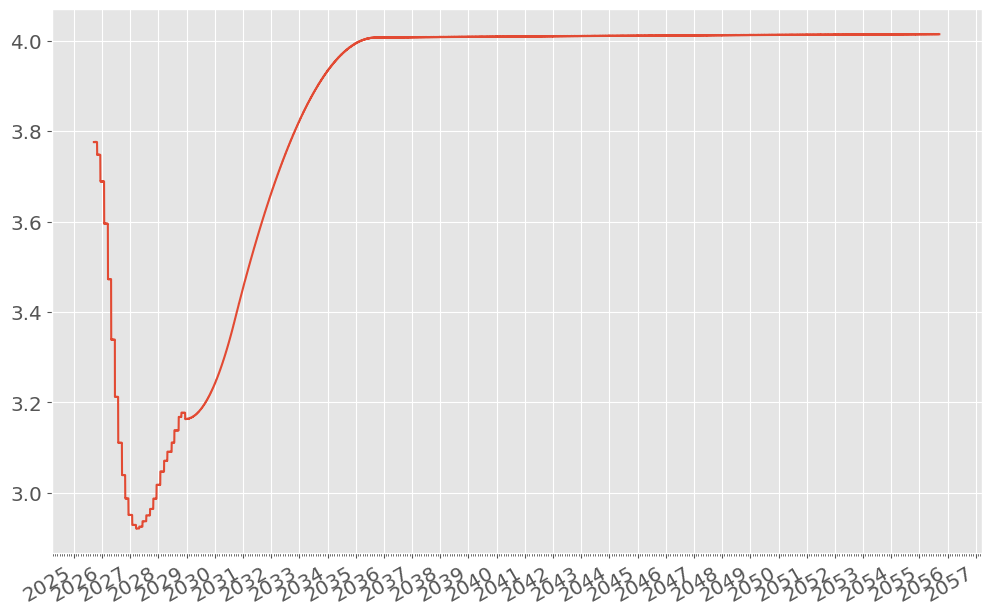

In [34]:
rlcurves_batch[intraday_range[306]].plot("1d")
# rlcurves_batch[intraday_range[318]].to_json()
# fives.rate(curves=rlcurves_batch[intraday_range[318]])

CACHE HIT...: 100%|██████████| 2/2 [00:00<00:00, 35.27it/s]


SUCCESS: `conv_tol` reached after 12 iterations (levenberg_marquardt), `f_val`: 7.598641192649327e-08, `time`: 0.0940s


(<Figure size 1200x800 with 1 Axes>,
 <Axes: >,
 [<matplotlib.lines.Line2D at 0x2418eb3b9d0>])

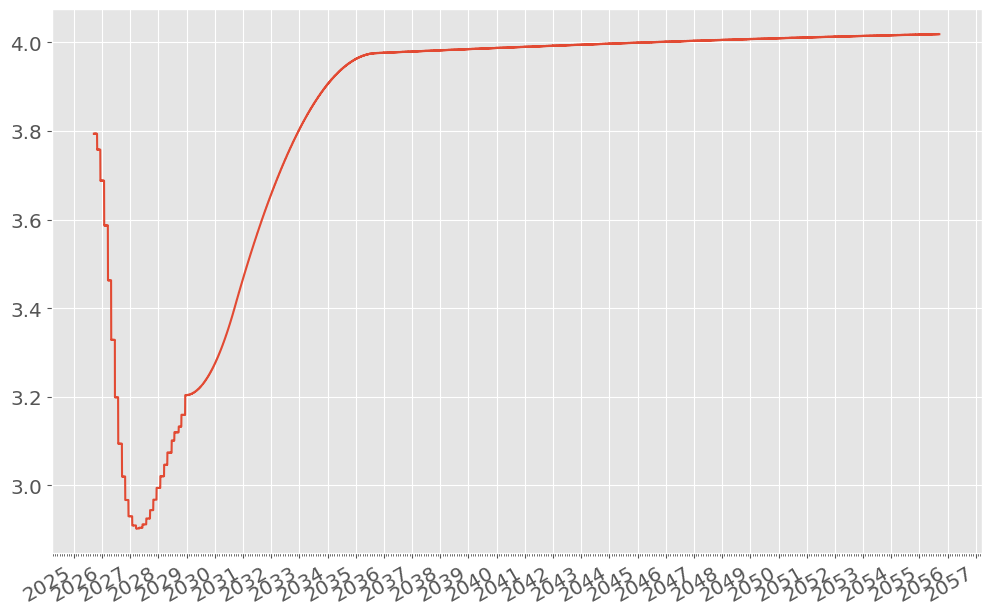

In [14]:
curve_mdp._get_curve(curve_name="USD-SOFR-1D", timestamp=intraday_range[318].to_pydatetime(), kwargs={"force_refresh": True}).handle().plot("1d")
# fives.rate(curves=curve_mdp._get_curve(curve_name="USD-SOFR-1D", timestamp=intraday_range[318].to_pydatetime(), kwargs={"force_refresh": False}).handle())

In [39]:
curve_mdp._get_curve(curve_name="USD-SOFR-1D", timestamp=intraday_range[318].to_pydatetime(), kwargs={"force_refresh": False}).handle().to_json()

'{"PyNative": {"Curve": {"meta": "{\\"PyNative\\": {\\"_CurveMeta\\": {\\"calendar\\": \\"{\\\\\\"NamedCal\\\\\\":{\\\\\\"name\\\\\\":\\\\\\"nyc\\\\\\"}}\\", \\"convention\\": \\"act360\\", \\"modifier\\": \\"MF\\", \\"index_base\\": \\"{\\\\\\"PyNative\\\\\\":{\\\\\\"NoInput\\\\\\":0}}\\", \\"index_lag\\": 0, \\"collateral\\": null, \\"credit_discretization\\": 23, \\"credit_recovery_rate\\": \\"0.4\\"}}}", "interpolator": "{\\"PyNative\\": {\\"_CurveInterpolator\\": {\\"local\\": \\"log_linear\\", \\"spline\\": \\"{\\\\\\"PyNative\\\\\\": {\\\\\\"_CurveSpline\\\\\\": {\\\\\\"t\\\\\\": [\\\\\\"2028-12-13\\\\\\", \\\\\\"2028-12-13\\\\\\", \\\\\\"2028-12-13\\\\\\", \\\\\\"2028-12-13\\\\\\", \\\\\\"2030-09-19\\\\\\", \\\\\\"2035-09-19\\\\\\", \\\\\\"2075-06-09\\\\\\", \\\\\\"2075-06-09\\\\\\", \\\\\\"2075-06-09\\\\\\", \\\\\\"2075-06-09\\\\\\"], \\\\\\"endpoints\\\\\\": [\\\\\\"natural\\\\\\", \\\\\\"natural\\\\\\"]}}}\\", \\"convention\\": \\"act360\\"}}}", "id": "2025-09-17 12:18:00-04